# Data Preprocessing

# Importing Libraries

In [65]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [66]:
df = pd.read_csv(r"C:\Users\aldiv\Downloads\CV\CV\Portofolio Data Science\Mini Project 3 Predict Customer Personality to Boost Marketing Campaign by Using Machine Learning\marketing_campaign_data.csv")
df.head()

,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntCoke,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,5524,1957,S1,Lajang,58138000.0,0,0,04-09-2012,58,635000,88000,546000,172000,88000,88000,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,1,2174,1954,S1,Lajang,46344000.0,1,1,08-03-2014,38,11000,1000,6000,2000,1000,6000,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,2,4141,1965,S1,Bertunangan,71613000.0,0,0,21-08-2013,26,426000,49000,127000,111000,21000,42000,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,3,6182,1984,S1,Bertunangan,26646000.0,1,0,10-02-2014,26,11000,4000,20000,10000,3000,5000,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,4,5324,1981,S3,Menikah,58293000.0,1,0,19-01-2014,94,173000,43000,118000,46000,27000,15000,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [67]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y', errors='coerce')
tanggal_terbaru = max(df['Dt_Customer'])
tanggal_terlama = min(df['Dt_Customer'])
print(f"The newest customer's enrollment date: {tanggal_terbaru}")
print(f"The oldest customer's enrollment date: {tanggal_terlama}")

The newest customer's enrollment date: 2014-06-29 00:00:00
The oldest customer's enrollment date: 2012-07-30 00:00:00


In [68]:
# Handling Dt_customer

# Change Dt_Customer to datetime
def feat_to_datetime(df):
    df['Enroll_day'] = df['Dt_Customer'].dt.day # The days enrolled
    df['Enroll_month'] = df['Dt_Customer'].dt.month # The month enrolled
    df['Enroll_year'] = df['Dt_Customer'].dt.year # The year enrolled
    max_enrollment_date = df['Dt_Customer'].max()
    df['Enroll_tenure (days)'] = (max_enrollment_date - df['Dt_Customer']).dt.days # Number of days since enrolled
    df = df.drop(columns=['ID', 'Unnamed: 0', 'Dt_Customer'], axis=1)
    return df
df = feat_to_datetime(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year_Birth            2240 non-null   int64  
 1   Education             2240 non-null   object 
 2   Marital_Status        2240 non-null   object 
 3   Income                2216 non-null   float64
 4   Kidhome               2240 non-null   int64  
 5   Teenhome              2240 non-null   int64  
 6   Recency               2240 non-null   int64  
 7   MntCoke               2240 non-null   int64  
 8   MntFruits             2240 non-null   int64  
 9   MntMeatProducts       2240 non-null   int64  
 10  MntFishProducts       2240 non-null   int64  
 11  MntSweetProducts      2240 non-null   int64  
 12  MntGoldProds          2240 non-null   int64  
 13  NumDealsPurchases     2240 non-null   int64  
 14  NumWebPurchases       2240 non-null   int64  
 15  NumCatalogPurchases  

In [69]:
# New feature before transformation
df['Total_Spending'] = df[['MntCoke', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df['Total_Spending'] = df['Total_Spending'].astype(float)

In [70]:
def check_unique_value(df):
    for i in df.columns:
        print(f"{i} \n {np.sort(df[i].unique())} \n")

check_unique_value(df)

Year_Birth 
 [1893 1899 1900 1940 1941 1943 1944 1945 1946 1947 1948 1949 1950 1951
 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963 1964 1965
 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977 1978 1979
 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993
 1994 1995 1996] 

Education 
 ['D3' 'S1' 'S2' 'S3' 'SMA'] 

Marital_Status 
 ['Bertunangan' 'Cerai' 'Duda' 'Janda' 'Lajang' 'Menikah'] 

Income 
 [1.73000e+06 2.44700e+06 3.50200e+06 ... 1.62397e+08 6.66666e+08
         nan] 

Kidhome 
 [0 1 2] 

Teenhome 
 [0 1 2] 

Recency 
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99] 

MntCoke 
 [      0    1000    2000    3000    4000    5000    6000    7000    8000
    9000   10000   11000   12000 

Z_CostContact and Z_Revenue has only one unique value, which is not giving much information for model machine learning. So, both features will be dropped

In [71]:
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'], axis=1)

# Checking Missing Value

In [72]:
def check_null(df):
    total_rows = len(df)
    null_counts = df.isnull().sum()
    null_percentage = (null_counts / total_rows * 100).round(2)

    null_df = pd.DataFrame({
        'Total_Null': null_counts,
        'Null_Percentage': null_percentage 
    })

    null_df = null_df.sort_values('Null_Percentage', ascending=False)
    null_df = null_df[null_df['Null_Percentage'] > 0]

    return null_df

In [73]:
null_analysis = check_null(df)
print("Total rows in dataset:", len(df))
print("\nNull Value Analysis:")
print(null_analysis)

Total rows in dataset: 2240

Null Value Analysis:
        Total_Null  Null_Percentage
Income          24             1.07


There are 1.07% missing values on Income feature. Since missing values percentage is under 5%, fill them will not change the whole data. We will fill them with median because median is robust from outliers. 

In [74]:
df['Income'].fillna(df['Income'].median(), inplace=True)

# Checking Duplicated Data

In [75]:
df.duplicated().sum()

np.int64(183)

There 183 duplicated data and will be dropped

In [76]:
df = df.drop_duplicates()

# Check Outliers

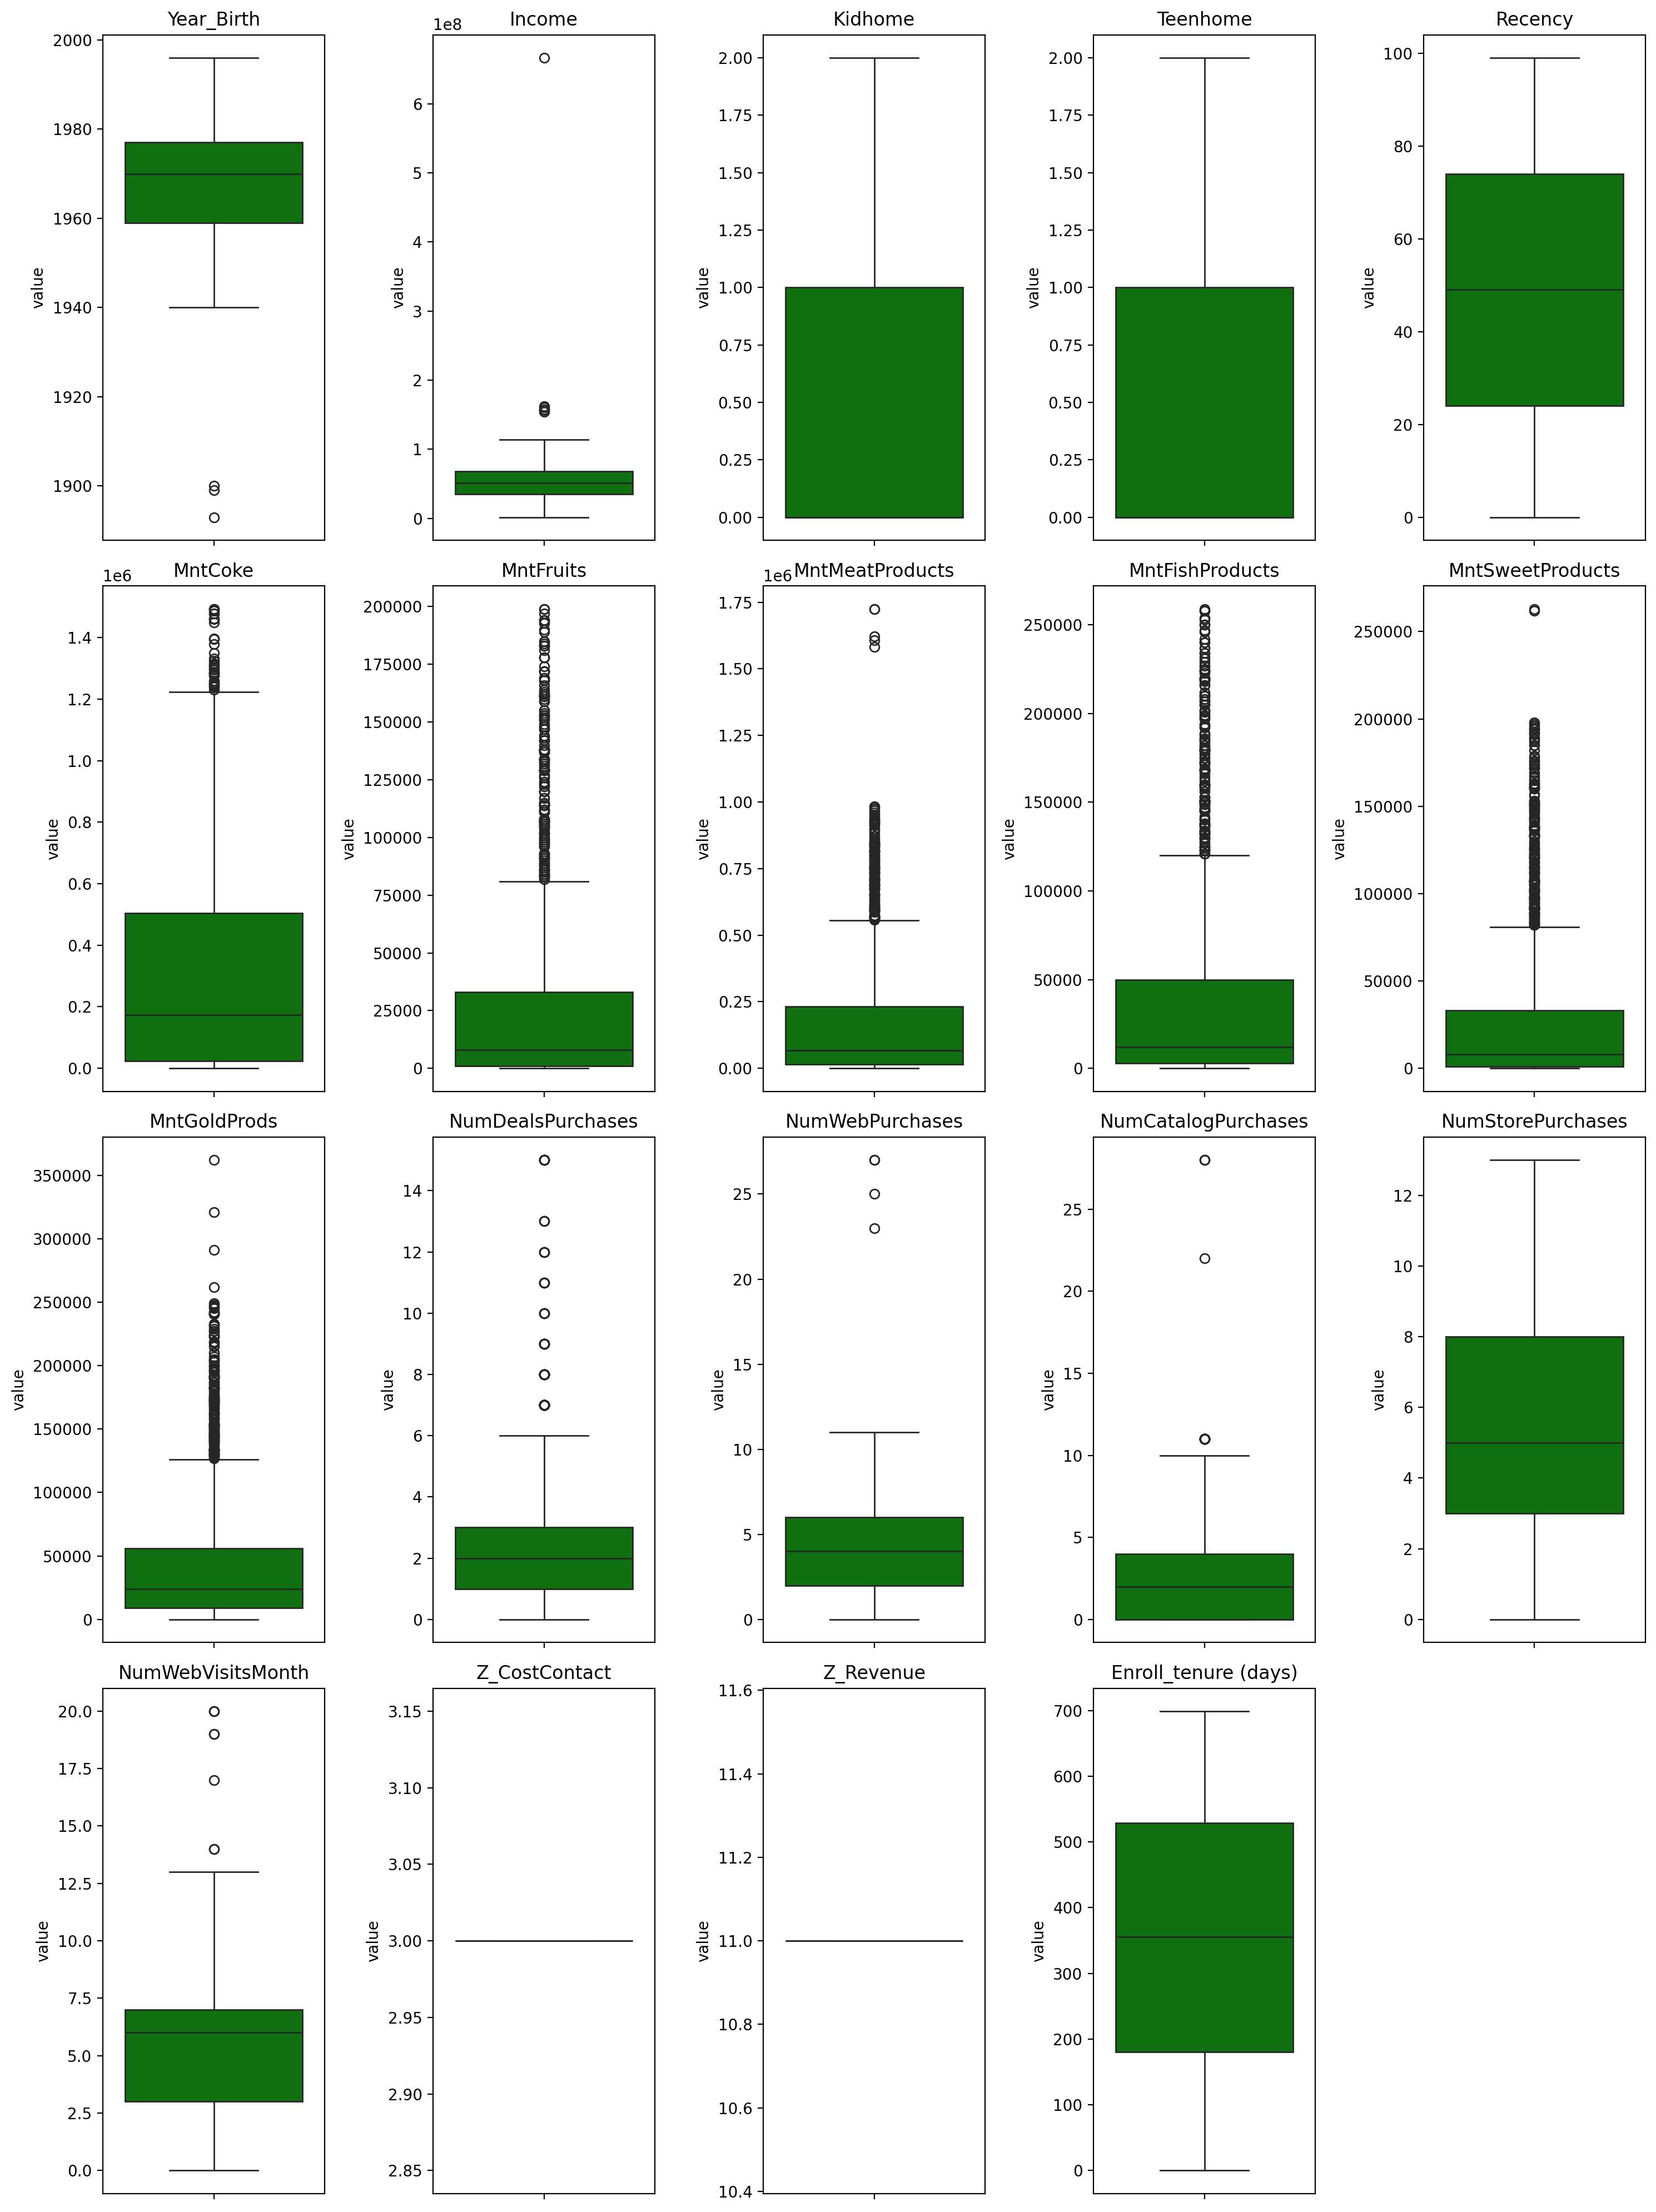

**Findings:**
- Income has an extreme outliers.
- Product purchase features have outliers.
- Year_Birth, NumDealsPurchases, NumWebPurchases, NumCatalogPurchases, and NumWebVisitsMonth have outliers but looks like not an anomaly, suggesting not to drop the outliers.

In [77]:
df_transform = df.copy()

## Income Feature

In [78]:
df_transform.loc[df_transform['Income'].nlargest(10).index]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntCoke,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Enroll_day,Enroll_month,Enroll_year,Enroll_tenure (days),Total_Spending
2233,1977,S1,Bertunangan,666666000.0,1,0,23,9000,14000,18000,8000,1000,12000,4,3,1,3,6,0,0,0,0,0,0,0,2,6,2013,392,62000.0
617,1976,S3,Bertunangan,162397000.0,1,1,31,85000,1000,16000,2000,1000,2000,0,0,0,1,1,0,0,0,0,0,0,0,3,6,2013,391,107000.0
687,1982,S3,Menikah,160803000.0,0,0,21,55000,16000,1622000,17000,3000,4000,15,0,28,1,0,0,0,0,0,0,0,0,4,8,2012,694,1717000.0
1300,1971,S2,Bertunangan,157733000.0,1,0,37,39000,1000,9000,2000,0,8000,0,1,0,1,1,0,0,0,0,0,0,0,4,6,2013,390,59000.0
164,1973,S3,Menikah,157243000.0,0,1,98,20000,2000,1582000,1000,2000,1000,15,0,22,0,0,0,0,0,0,0,0,0,1,3,2014,120,1608000.0
1653,1977,S1,Bertunangan,157146000.0,0,0,13,1000,0,1725000,2000,1000,1000,0,0,28,0,1,0,0,0,0,0,0,0,29,4,2013,426,1730000.0
2132,1949,S3,Menikah,156924000.0,0,0,85,2000,1000,2000,1000,1000,1000,0,0,0,0,0,0,0,0,0,0,0,0,29,8,2013,304,8000.0
655,1975,S1,Cerai,153924000.0,0,0,81,1000,1000,1000,1000,1000,1000,0,0,0,0,0,0,0,0,0,0,0,0,7,2,2014,142,6000.0
1898,1945,S3,Lajang,113734000.0,0,0,9,6000,2000,3000,1000,262000,3000,0,27,0,0,1,0,0,0,0,0,0,0,28,5,2014,32,277000.0
646,1970,S1,Bertunangan,105471000.0,0,0,36,1009000,181000,104000,202000,21000,207000,0,9,8,13,3,0,0,1,1,0,0,1,21,1,2013,524,1724000.0


Based on exploratory data analysis, we found:
- The outliers start from 150 Million
- There are eight outliers in this feature
- From eight people, five people have become customers for around 1 year, one person become customers for two years, and two people had enrolled under one year.
- We think customer with **666 Million** income are anomaly will considered to be **dropped**.

## Product Purchases Feature

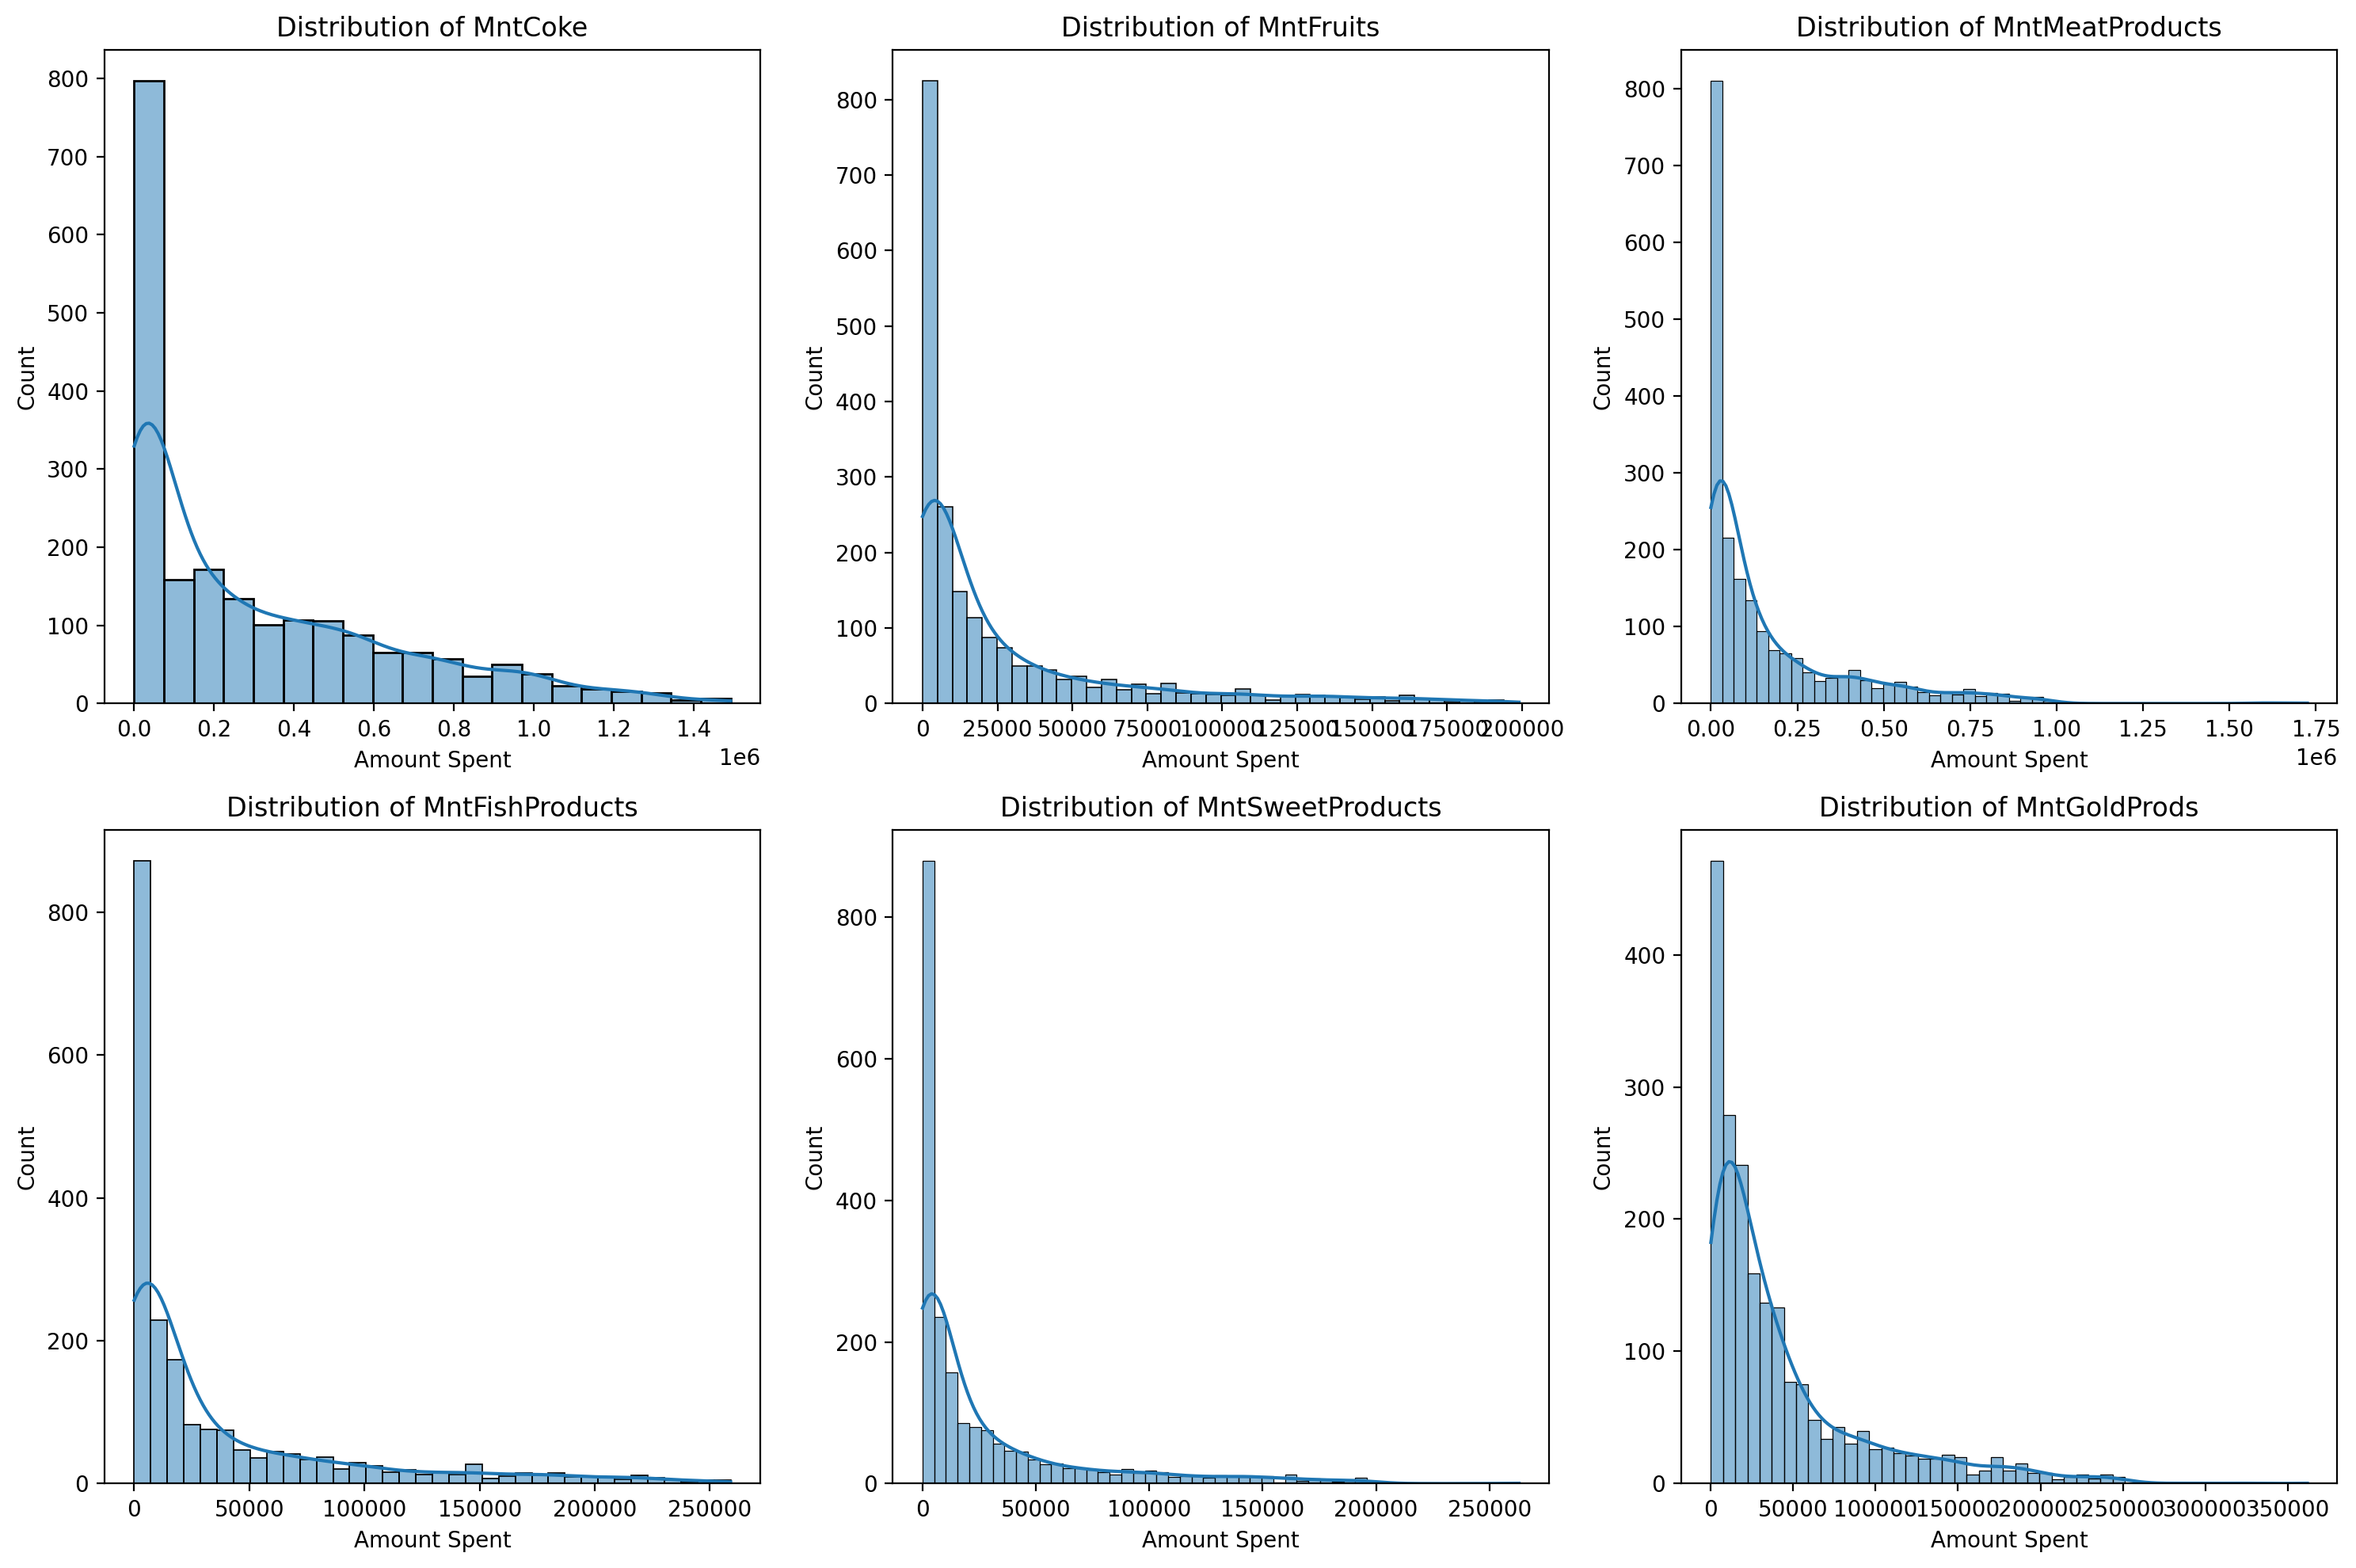

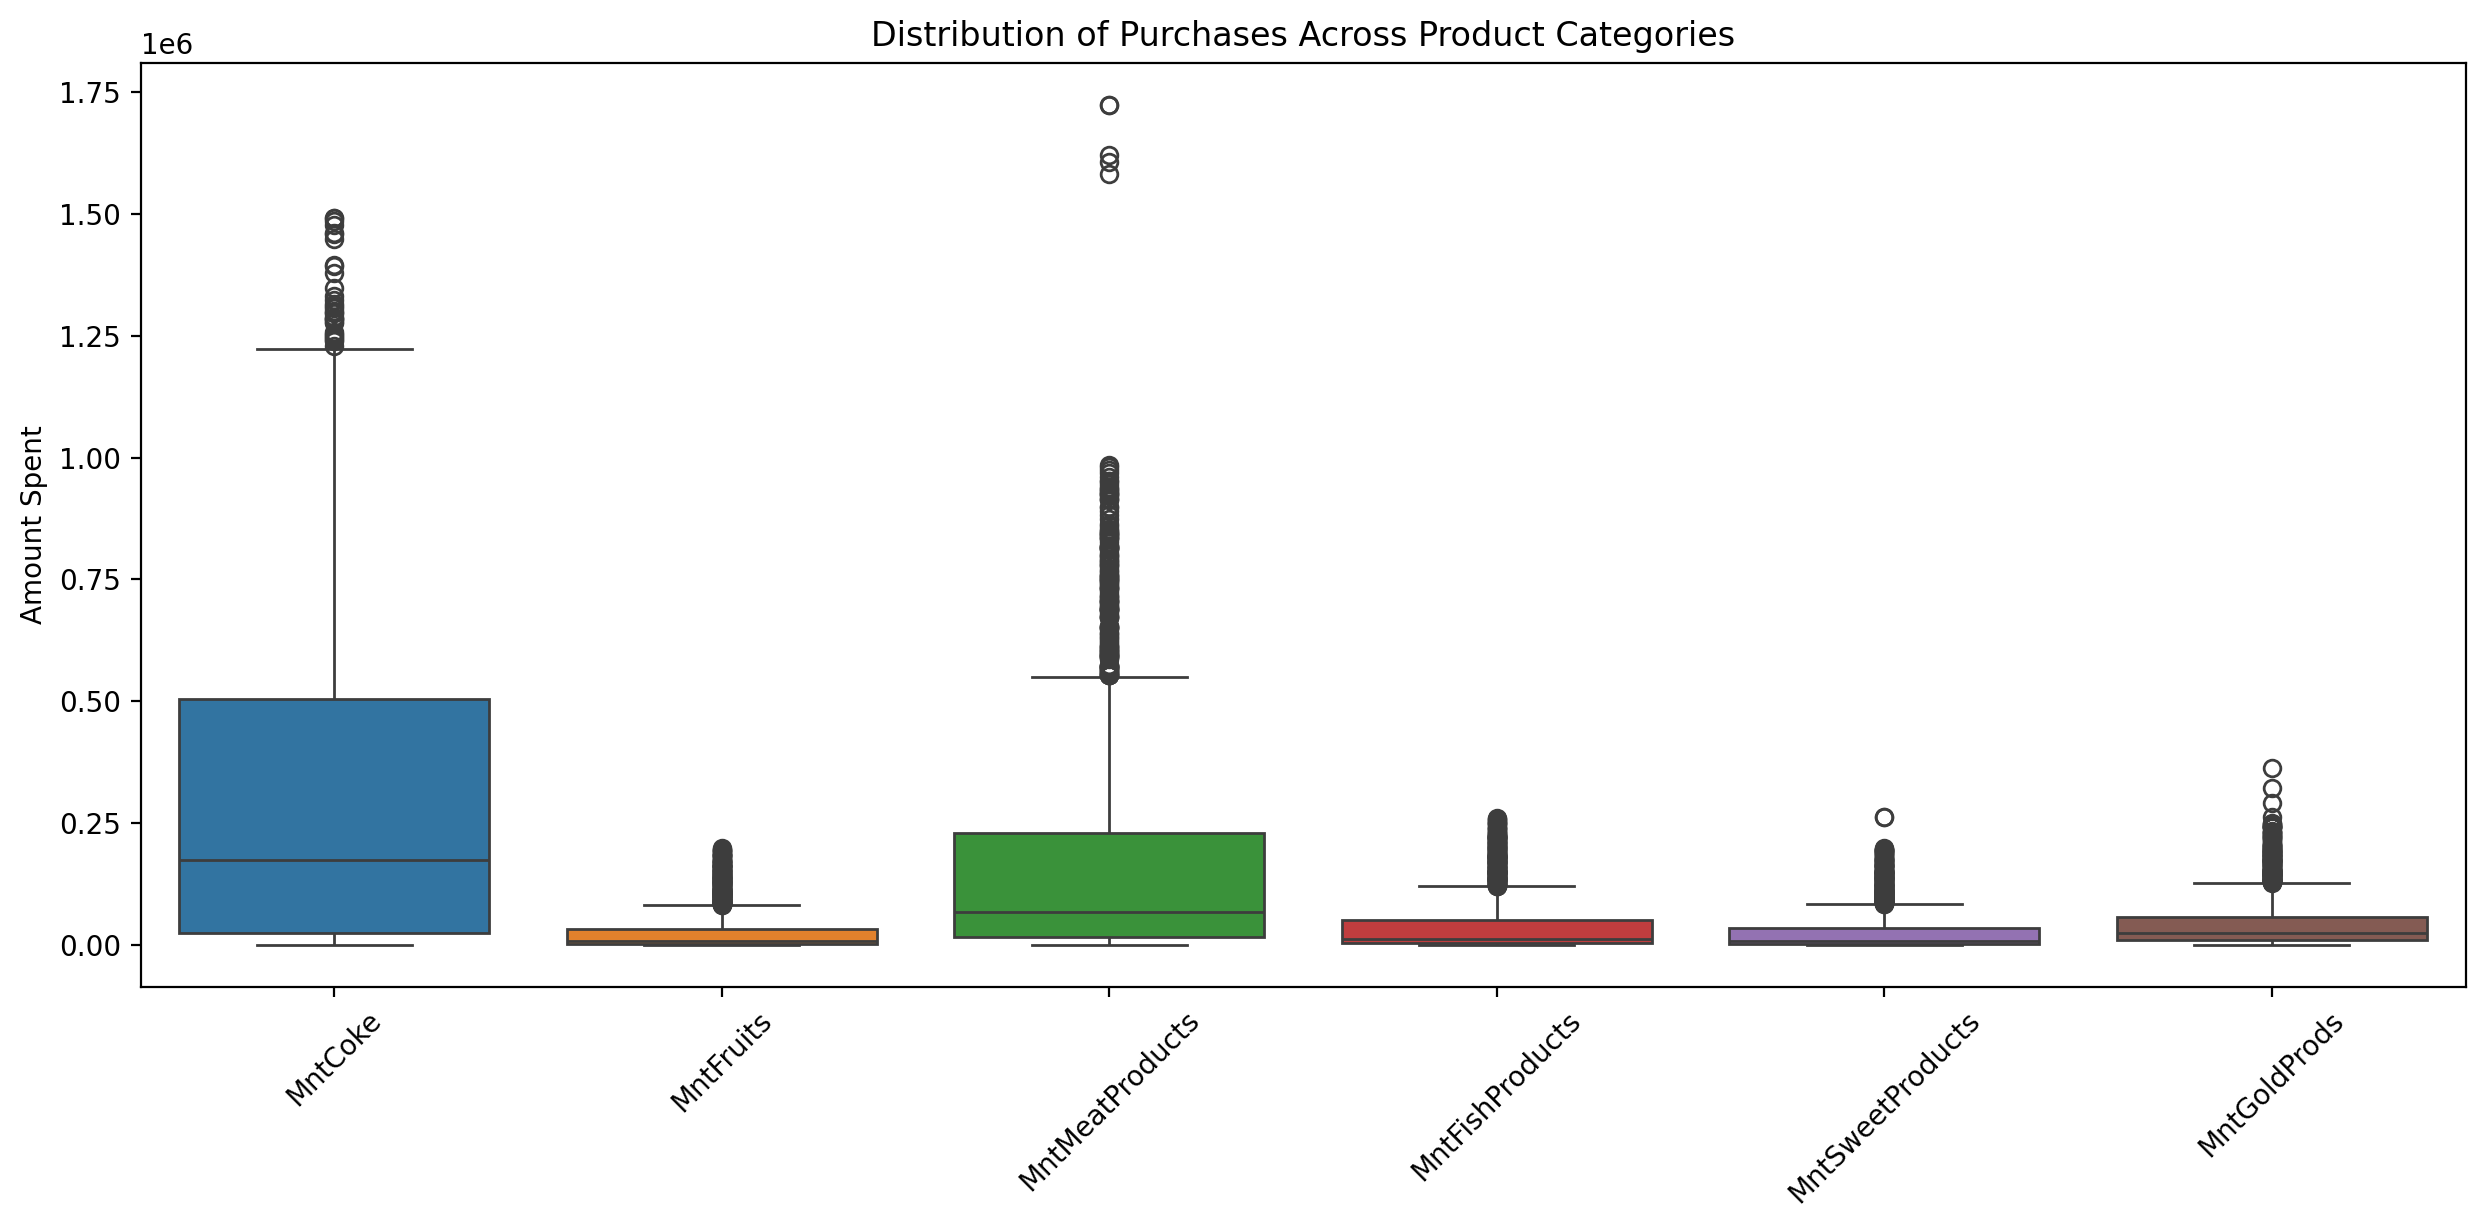

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.figure(figsize=(15, 10), dpi=200)

# List of product categories
categories = ['MntCoke', 'MntFruits', 'MntMeatProducts', 
             'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# Create distribution plot for each category
for i, category in enumerate(categories, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df_transform, x=category, kde=True)
    plt.title(f'Distribution of {category}')
    plt.xlabel('Amount Spent')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Alternative using boxplots
plt.figure(figsize=(15, 6), dpi=200)
sns.boxplot(data=df_transform[categories])
plt.xticks(rotation=45)
plt.title('Distribution of Purchases Across Product Categories')
plt.ylabel('Amount Spent')
plt.show()

## Year_Birth, NumDealsPurchases, NumWebPurchases, NumCatalogPurchases, and NumWebVisitsMonth

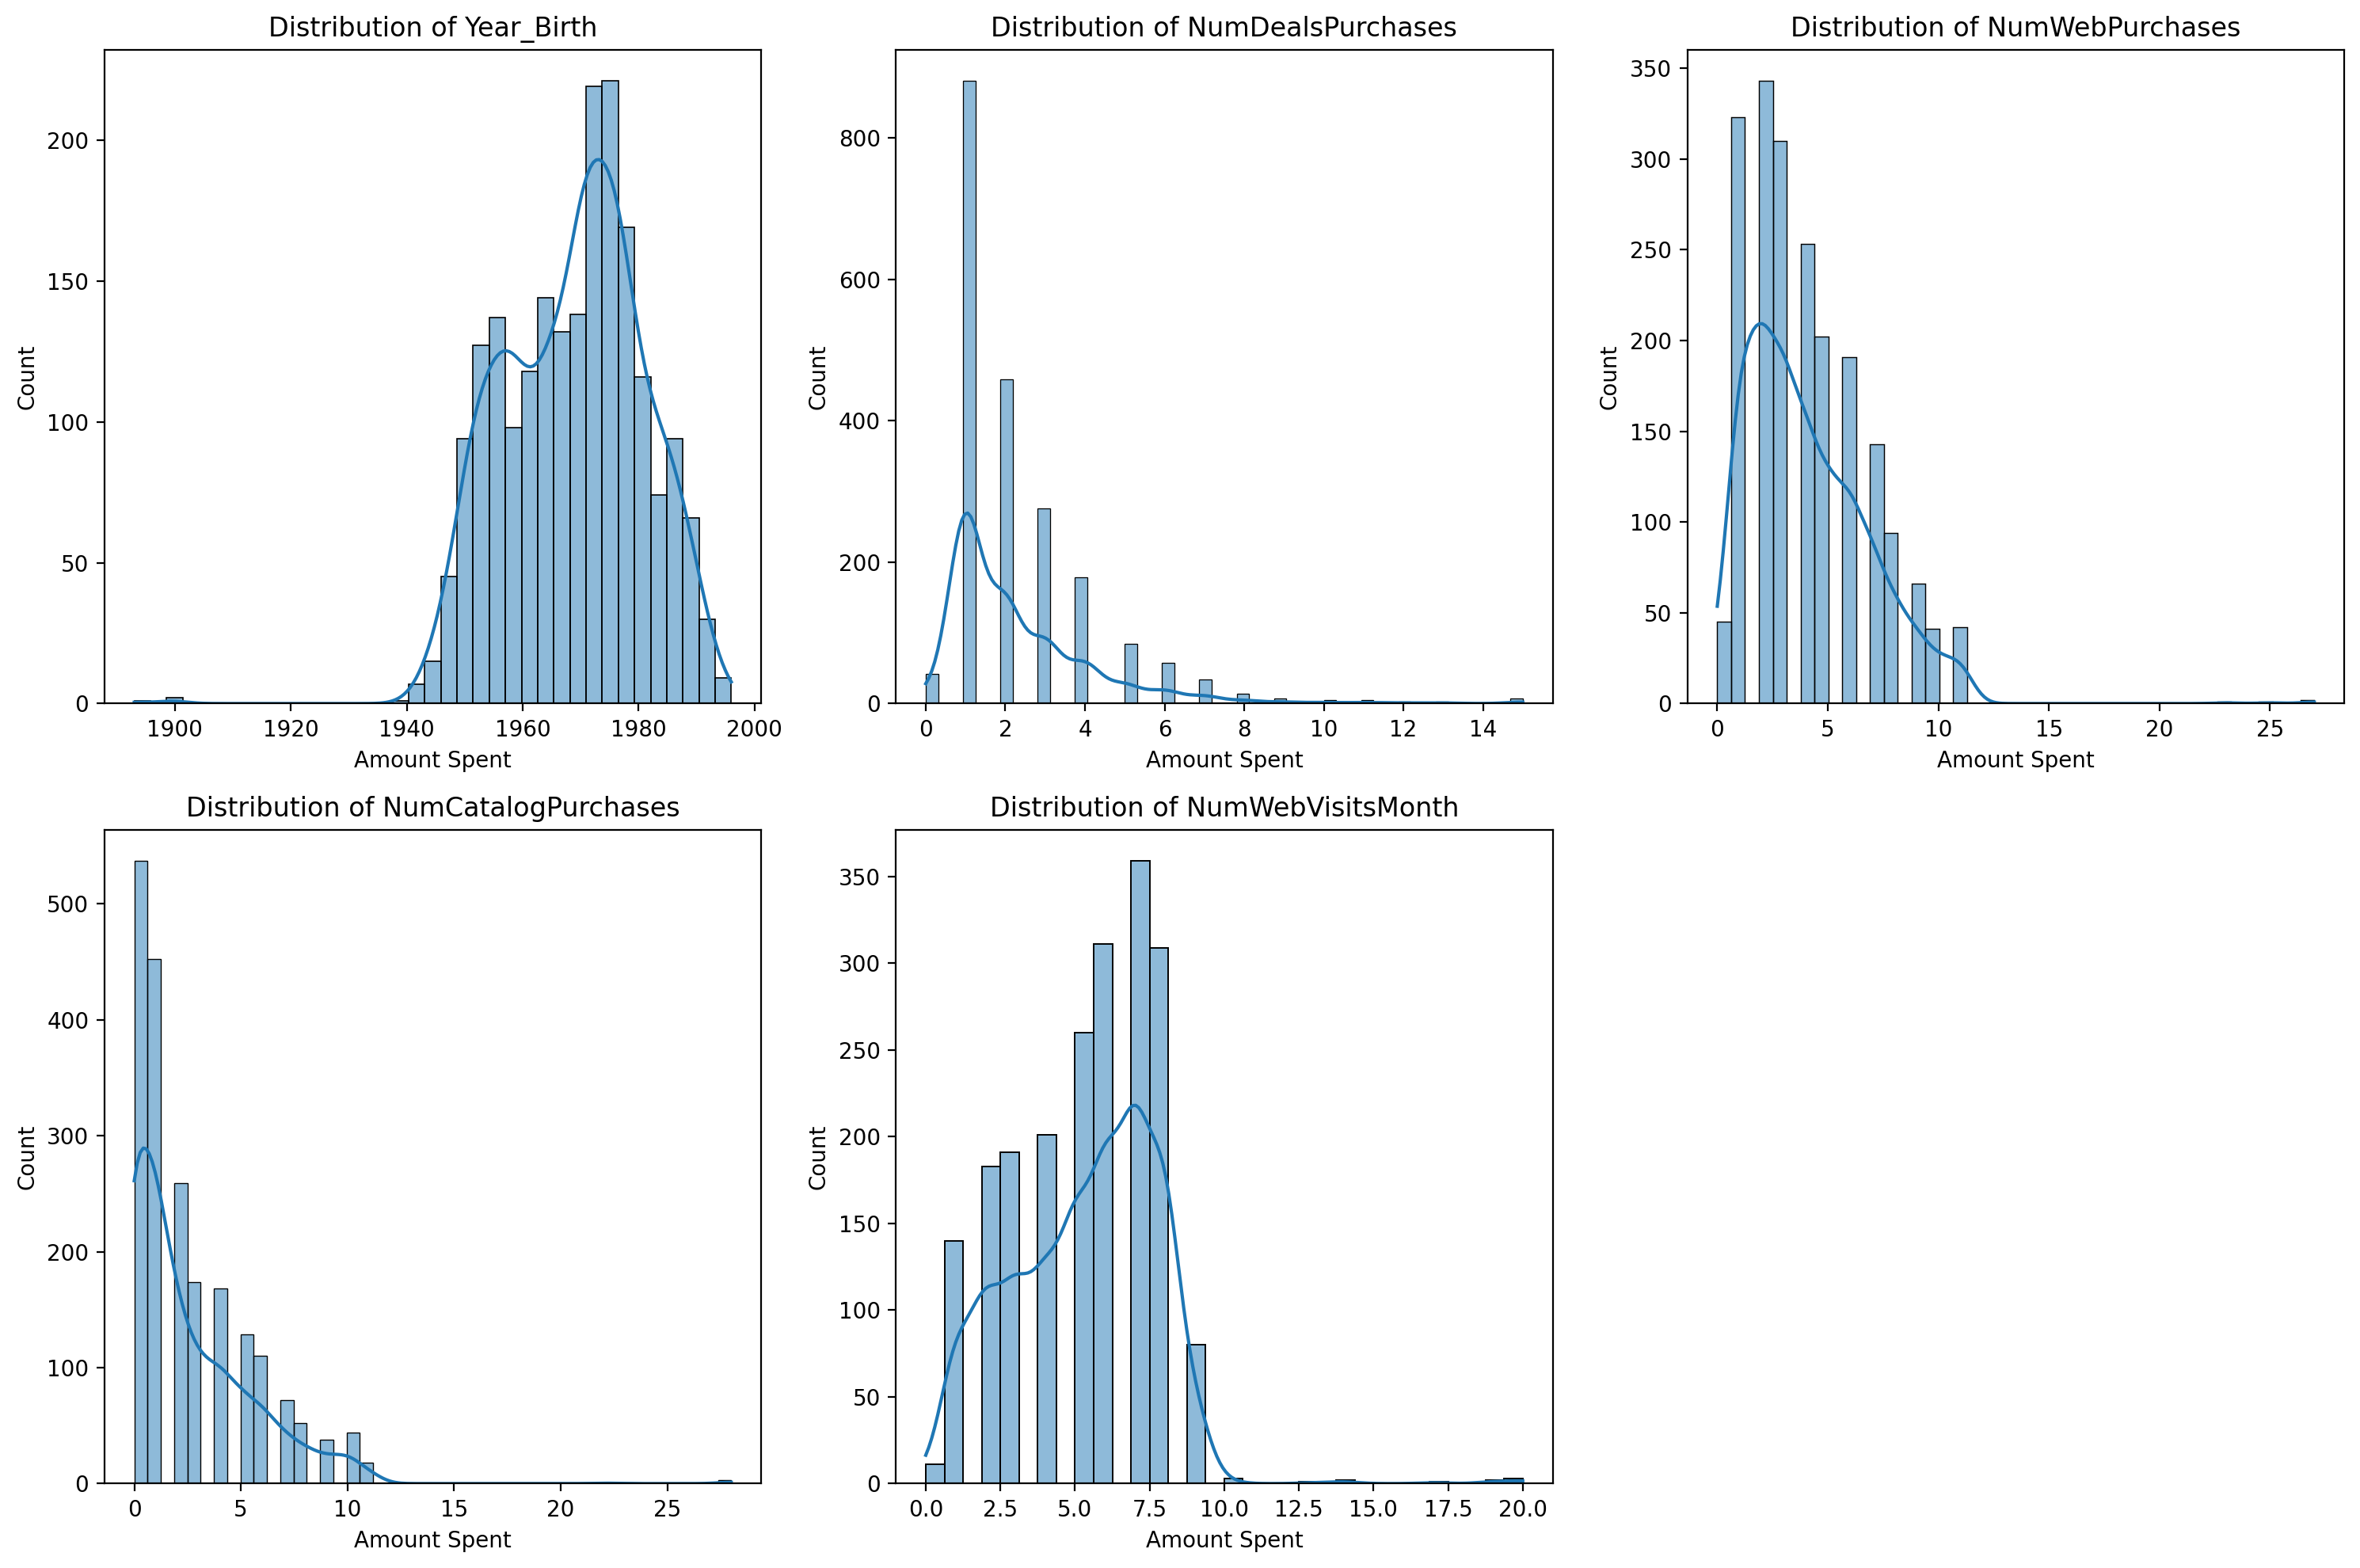

In [80]:
plt.figure(figsize=(15, 10), dpi=200)

# List of product categories
categories = ['Year_Birth', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumWebVisitsMonth']

# Create distribution plot for each category
for i, category in enumerate(categories, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df_transform, x=category, kde=True)
    plt.title(f'Distribution of {category}')
    plt.xlabel('Amount Spent')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


## Feature Transformation

All of features are right-skewed, except Year_Birth. These features will be feature transformed with log transformation to make the distribution more normal.

In [81]:
def feat_transform(df):
    df = df[df['Income'] < df['Income'].max()]

    columns = [ 
        'Income', 'MntCoke', 'MntFruits', 'MntMeatProducts', 
        'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
        'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumWebVisitsMonth'
    ]
    for i in columns:
        df[i + '_log'] = np.log1p(df[i])
        df = df.drop(columns=[i])
    return df

In [82]:
df_transform1 = feat_transform(df_transform)

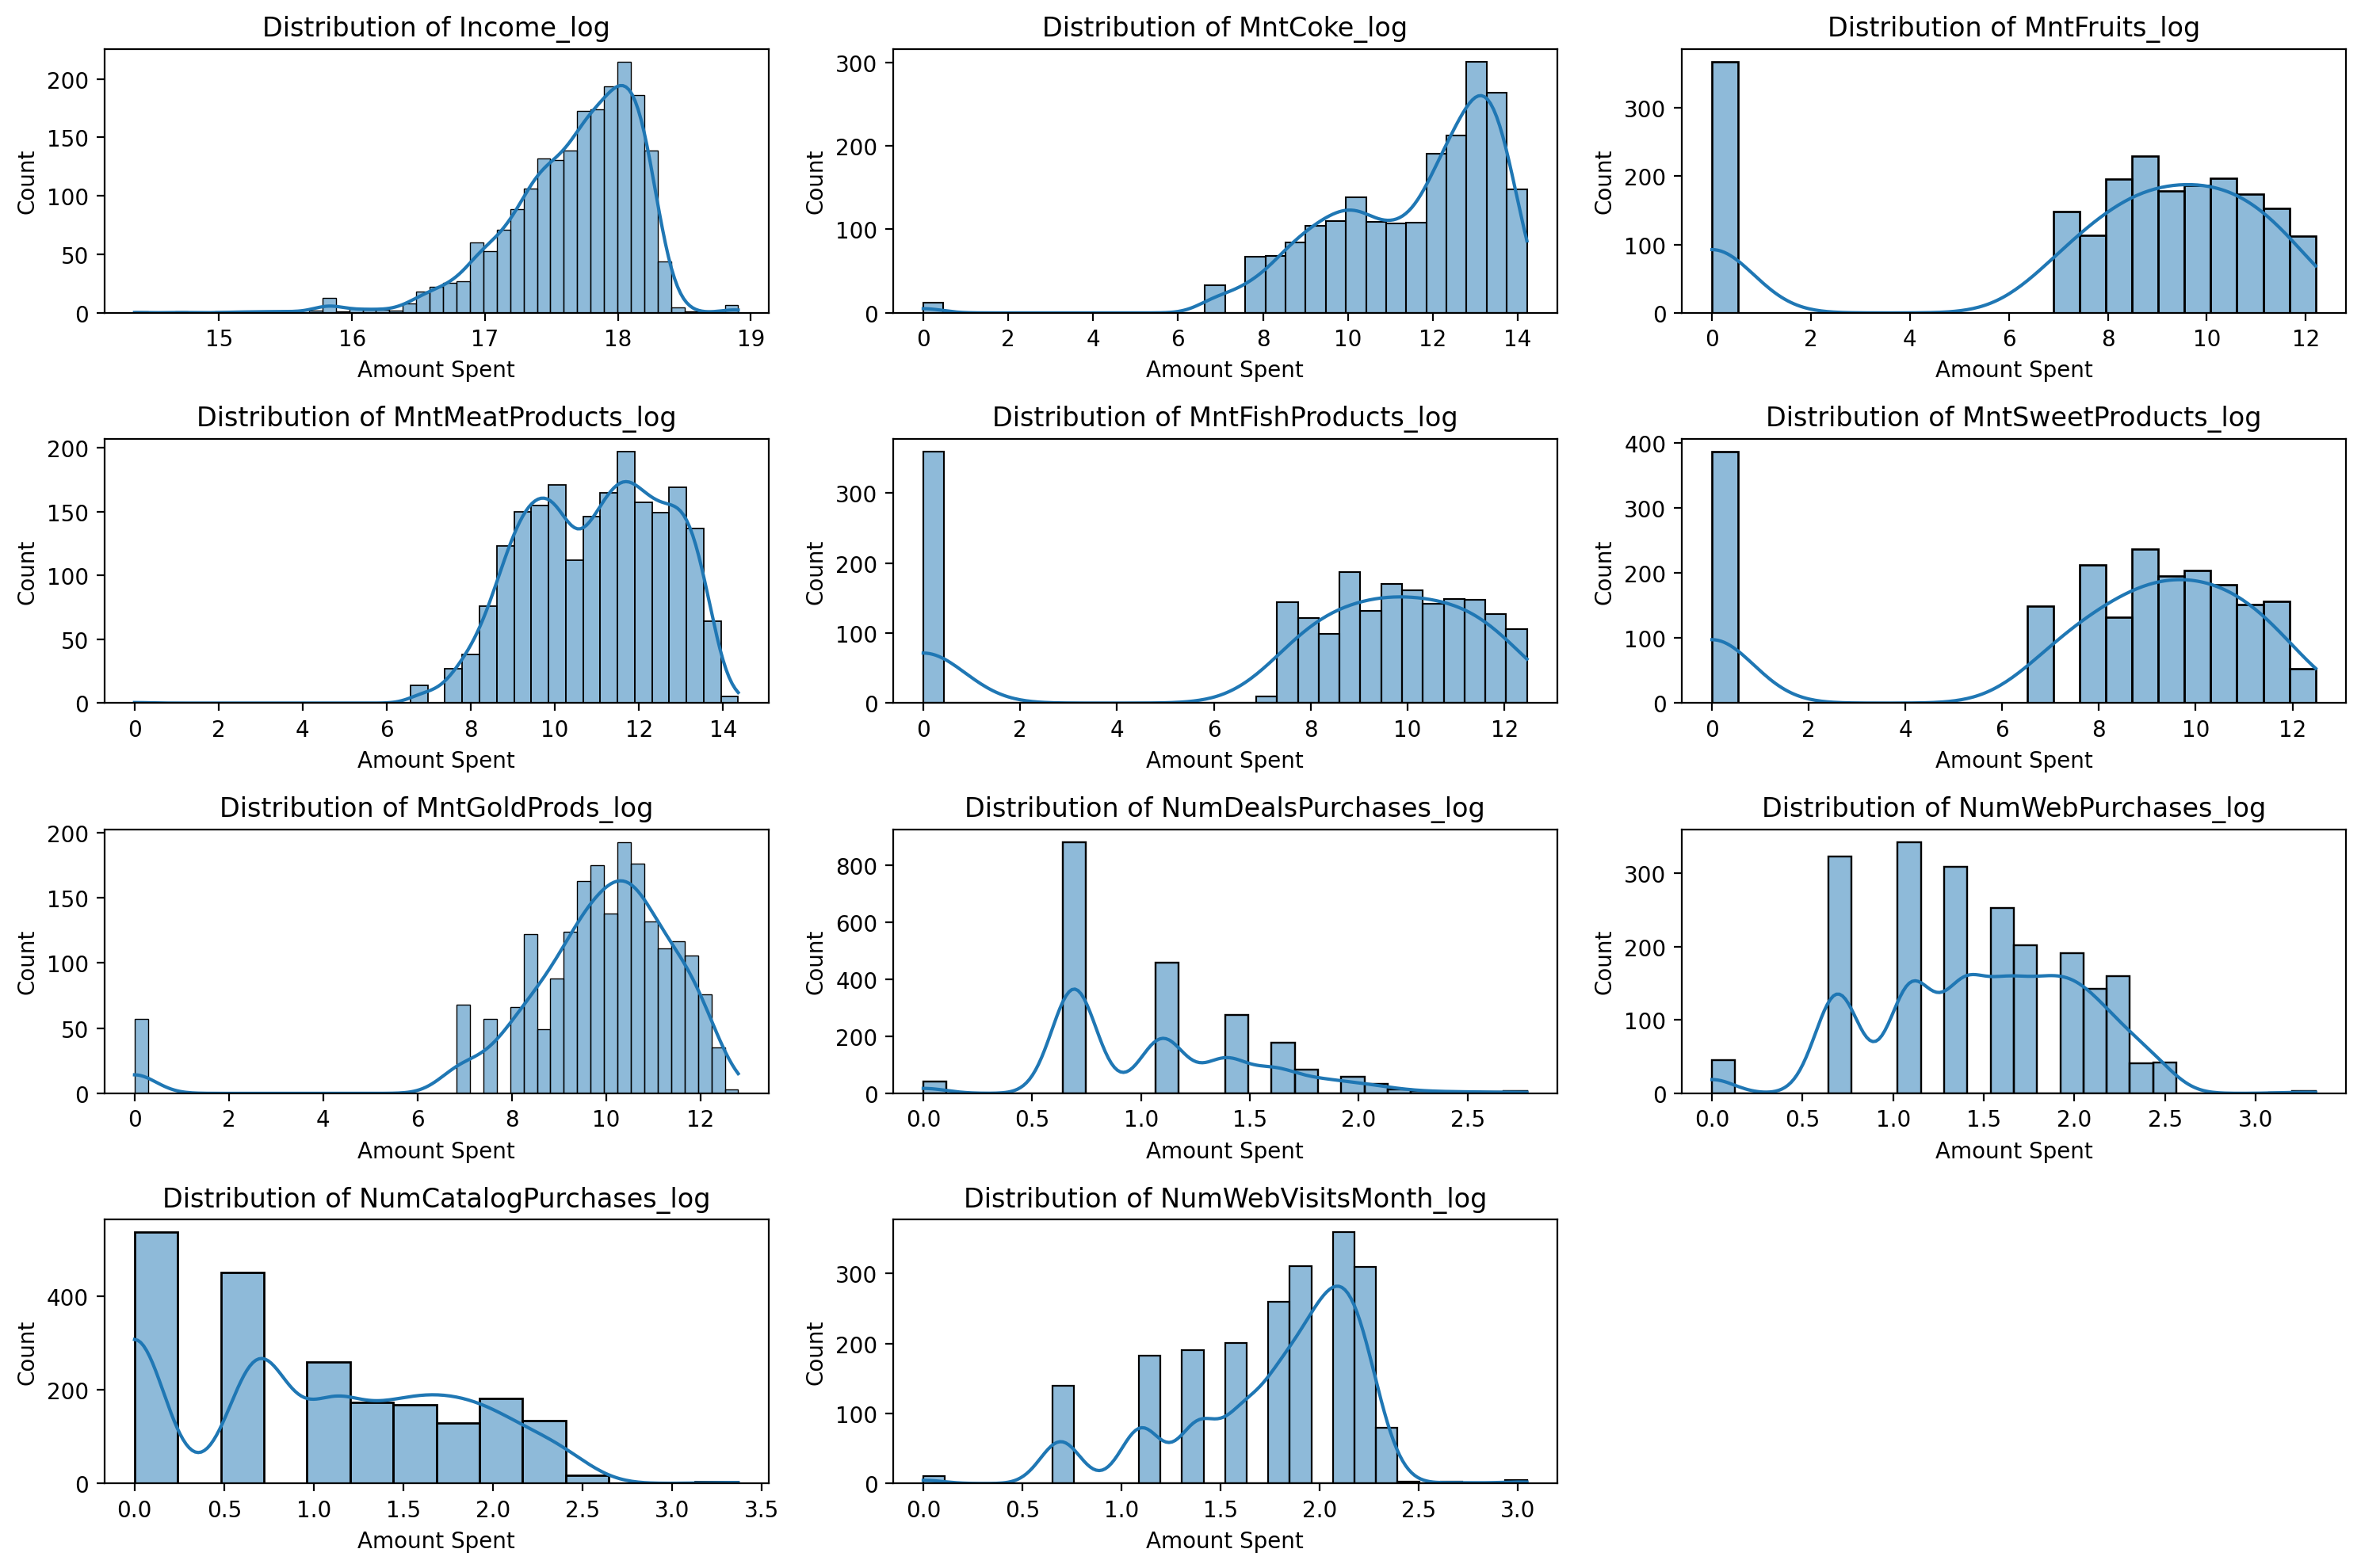

In [83]:
plt.figure(figsize=(15, 10), dpi=200)

# List of product categories
categories = ['Income_log', 'MntCoke_log', 'MntFruits_log', 'MntMeatProducts_log',
       'MntFishProducts_log', 'MntSweetProducts_log', 'MntGoldProds_log',
       'NumDealsPurchases_log', 'NumWebPurchases_log',
       'NumCatalogPurchases_log', 'NumWebVisitsMonth_log']

# Create distribution plot for each category
for i, category in enumerate(categories, 1):
    plt.subplot(4, 3, i)
    sns.histplot(data=df_transform1, x=category, kde=True)
    plt.title(f'Distribution of {category}')
    plt.xlabel('Amount Spent')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [84]:
def feat_transform(df):
    # Filter out outliers in Income
    df = df[df['Income'] < df['Income'].max()]

    # Define monetary columns to transform
    monetary_columns = [ 
        'Income', 'MntCoke', 'MntFruits', 'MntMeatProducts', 
        'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
    ]

    # Create log transformed columns for monetary features and drop original ones
    for column in monetary_columns:
        df[column + '_log'] = np.log1p(df[column])
        df = df.drop(columns=[column])

    return df

In [85]:
df_transform2 = feat_transform(df_transform)

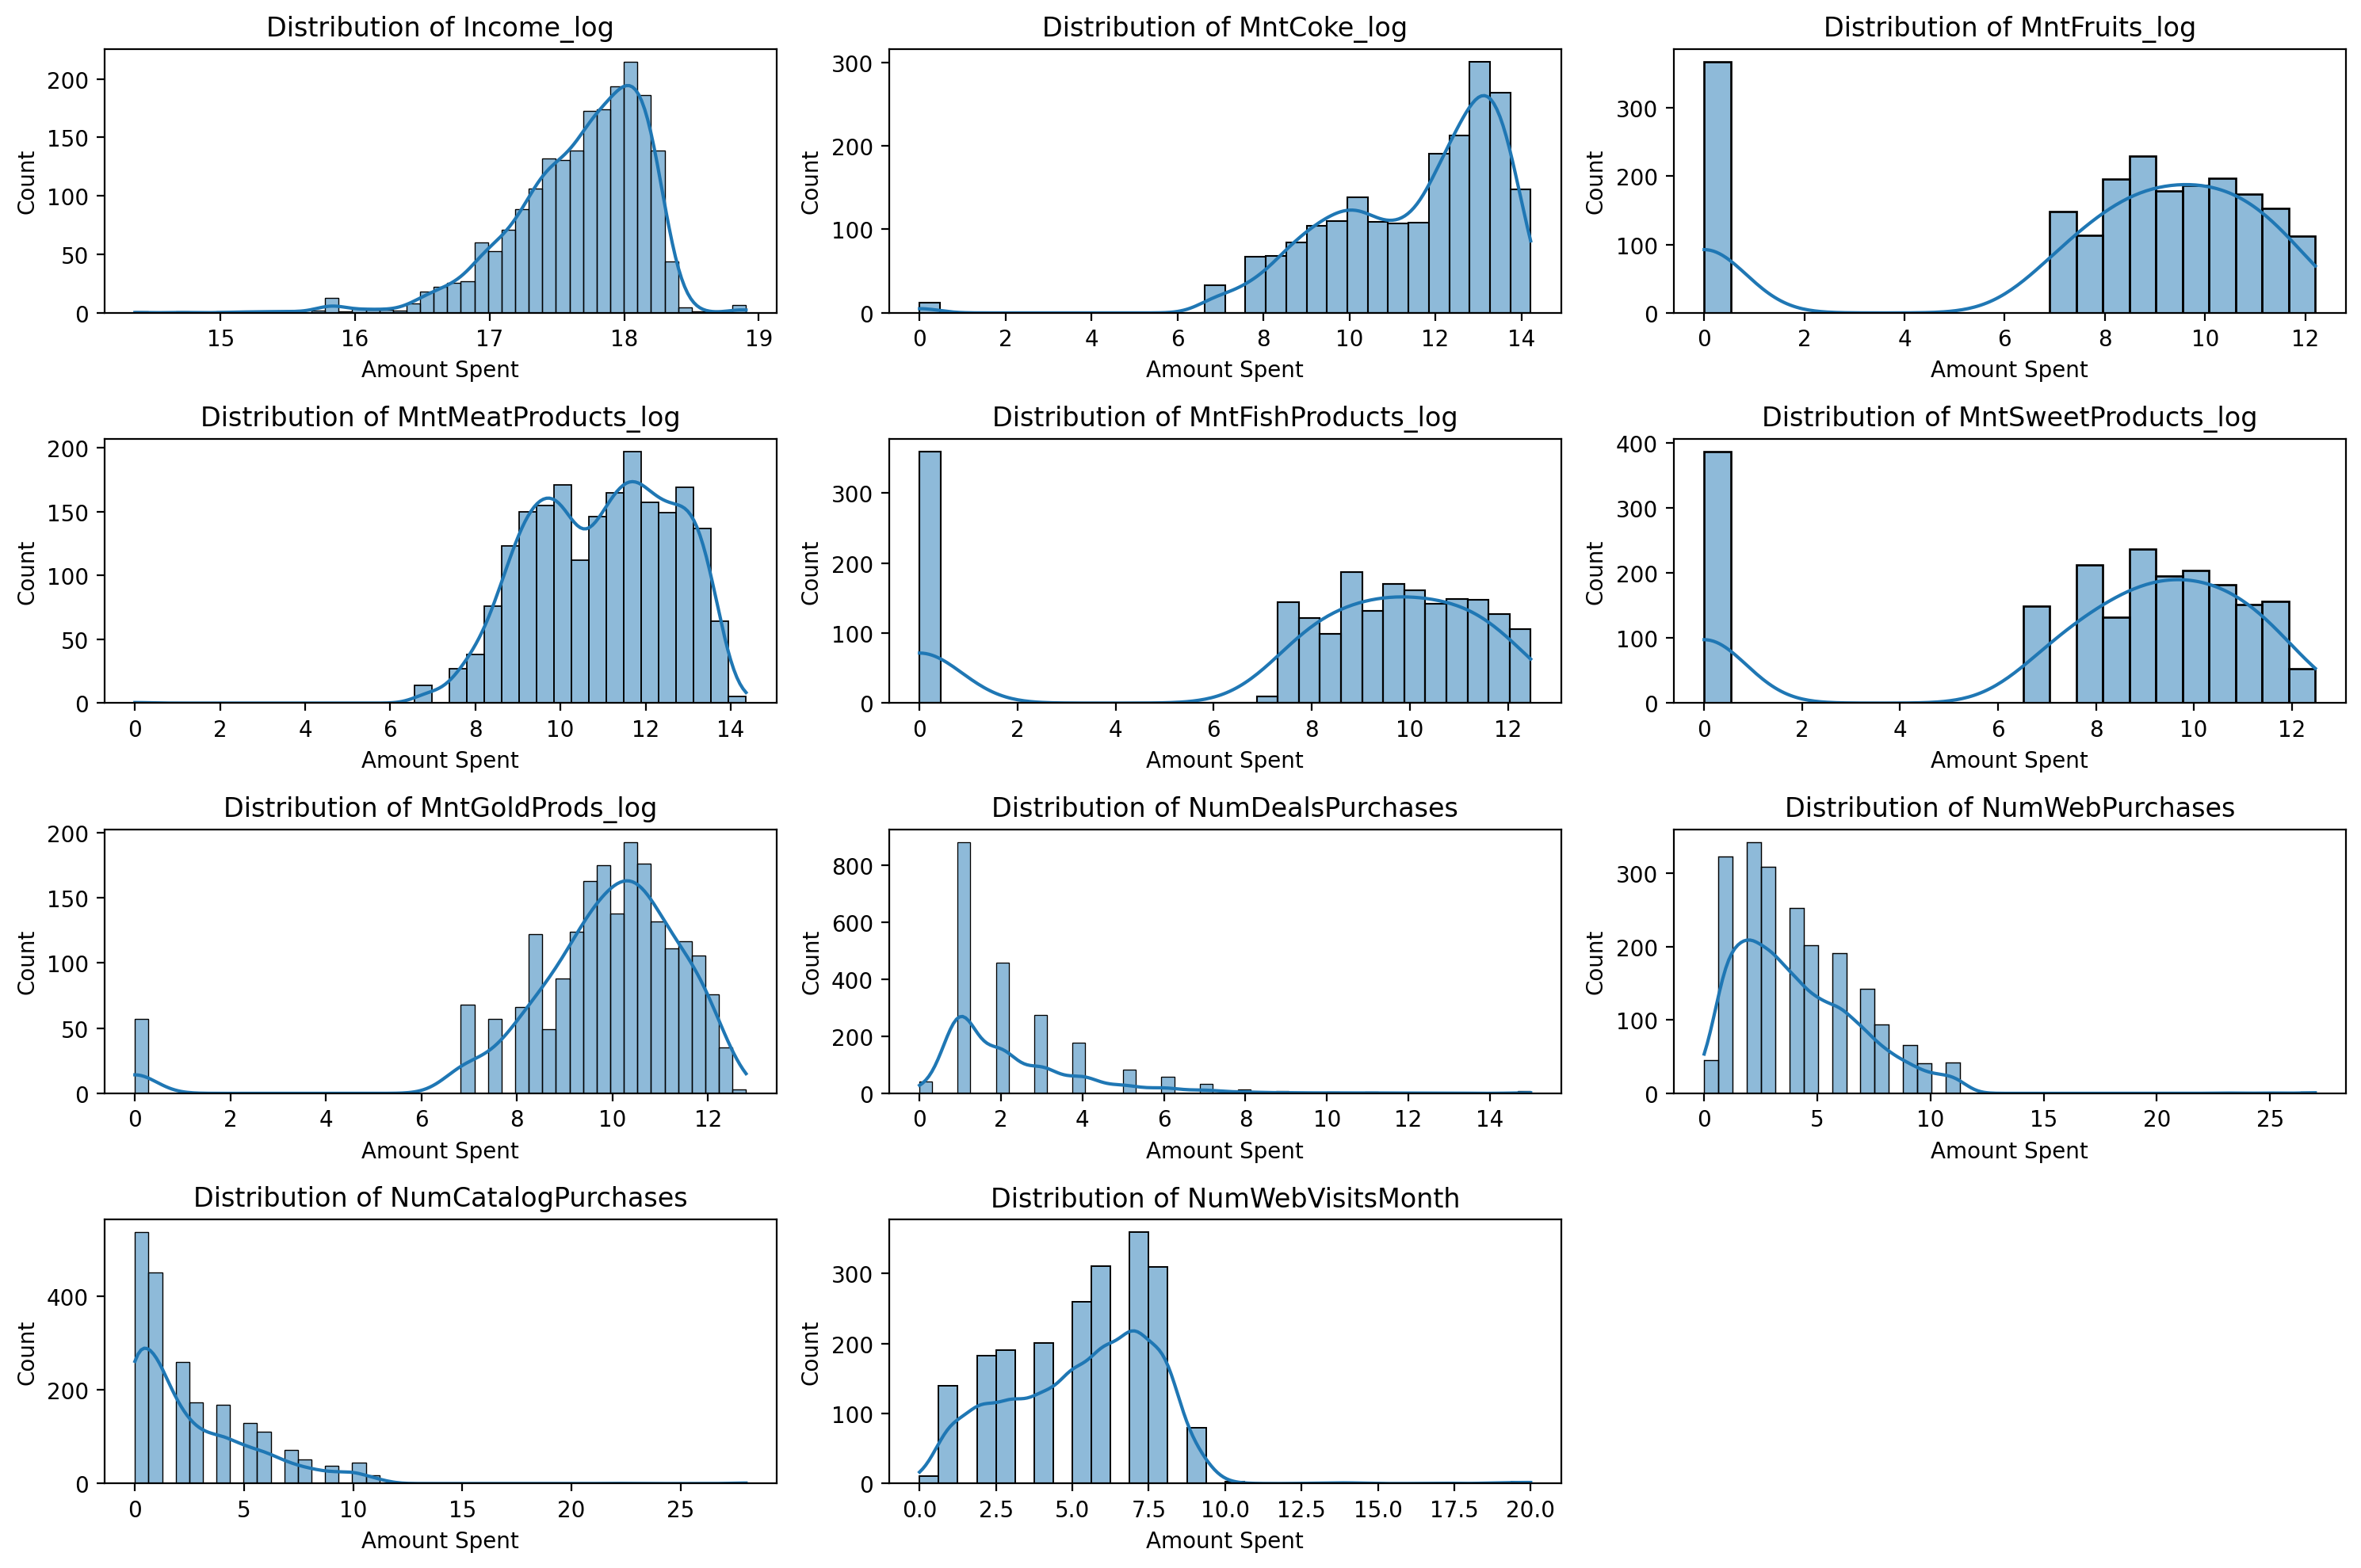

In [86]:
plt.figure(figsize=(15, 10), dpi=200)

# List of product categories
categories = ['Income_log', 'MntCoke_log', 'MntFruits_log', 'MntMeatProducts_log',
       'MntFishProducts_log', 'MntSweetProducts_log', 'MntGoldProds_log',
       'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumWebVisitsMonth']

# Create distribution plot for each category
for i, category in enumerate(categories, 1):
    plt.subplot(4, 3, i)
    sns.histplot(data=df_transform2, x=category, kde=True)
    plt.title(f'Distribution of {category}')
    plt.xlabel('Amount Spent')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

We will keep the "Num" features because they have a normal scale instead of Income and Product purchases features.

# Feature Encoding

In [87]:
df_label = df_transform2.copy()
df_label.select_dtypes('object').columns

Index(['Education', 'Marital_Status'], dtype='object')

In [88]:
columns = df_label.select_dtypes('object').columns
for i in df[columns]:
    print(df[i].unique())

['S1' 'S3' 'S2' 'SMA' 'D3']
['Lajang' 'Bertunangan' 'Menikah' 'Cerai' 'Janda' 'Duda']


It appears the Education has an ordinal value while Marital_Status not. So, we will label encoding for Education feature and one hot encoding for Marital_Status

In [89]:
from sklearn.preprocessing import LabelEncoder

def feat_encode(df):
    df['Education'] = df['Education'].replace({'SMA': 0, 'D3': 1, 'S1': 2, 'S2': 3, 'S3': 4})

    df['Marital_Status'] = df['Marital_Status'].replace({'Janda': 'Cerai', 'Duda': 'Cerai'})

    marital_dummies = pd.get_dummies(df['Marital_Status'], prefix='Status_')

    df = pd.concat([df, marital_dummies], axis=1)
    df.drop(columns=['Marital_Status'], inplace=True)
    
    dtype = df.select_dtypes('bool').columns
    df[dtype] = df[dtype].astype(int) 
    return df

df_label = feat_encode(df_label)

In [90]:
df_label.columns

Index(['Year_Birth', 'Education', 'Kidhome', 'Teenhome', 'Recency',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'Enroll_day', 'Enroll_month', 'Enroll_year',
       'Enroll_tenure (days)', 'Total_Spending', 'Income_log', 'MntCoke_log',
       'MntFruits_log', 'MntMeatProducts_log', 'MntFishProducts_log',
       'MntSweetProducts_log', 'MntGoldProds_log', 'Status__Bertunangan',
       'Status__Cerai', 'Status__Lajang', 'Status__Menikah'],
      dtype='object')

# Feature Engineering

In [91]:
df_FE = df_label.copy()
def feat_engineering(df):
    # Age Feature 
    df['Age'] = max(df['Enroll_year']) - df['Year_Birth']

    # Total Spending on all products
    df['Total_Spending_log'] = df['MntCoke_log'] + df['MntFruits_log'] + df['MntMeatProducts_log'] + df['MntFishProducts_log'] + df['MntSweetProducts_log'] + df['MntGoldProds_log']

    # Total Children
    df['Children'] = df['Kidhome'] + df['Teenhome']

    # A parent
    df['is_parent'] = (df['Children'] > 0).astype(int)

    # Rename columns
    df = df.rename(columns={'Kidhome': 'Kid', 'Teenhome': 'Teen',
                            'NumDealsPurchases': 'Deals_Purchases', 'NumWebPurchases': 'Web_Purchases', 'NumCatalogPurchases': 'Catalog_Purchases',
                            'NumStorePurchases': 'Store_Purchases', 'NumWebVisitsMonth': 'Web_Visits',
                            'AcceptedCmp1': 'Campaign_1', 'AcceptedCmp2': 'Campaign_2', 'AcceptedCmp3': 'Campaign_3', 'AcceptedCmp4': 'Campaign_4',
                            'AcceptedCmp5': 'Campaign_5',
                            'Income_log': 'Income', 'MntCoke_log': 'Coke', 'MntFruits_log': 'Fruits', 'MntMeatProducts_log': 'Meat',
                            'MntFishProducts_log': 'Fish', 'MntSweetProducts_log': 'Sweet', 'MntGoldProds_log': 'Gold'})

    # Remove feature
    df = df.drop(columns=['Year_Birth'])

    return df

df_FE = feat_engineering(df_FE)

In [92]:
df_FE.head()

,Education,Kid,Teen,Recency,Deals_Purchases,Web_Purchases,Catalog_Purchases,Store_Purchases,Web_Visits,Campaign_3,Campaign_4,Campaign_5,Campaign_1,Campaign_2,Complain,Response,Enroll_day,Enroll_month,Enroll_year,Enroll_tenure (days),Total_Spending,Income,Coke,Fruits,Meat,Fish,Sweet,Gold,Status__Bertunangan,Status__Cerai,Status__Lajang,Status__Menikah,Age,Total_Spending_log,Children,is_parent
0,2,0,0,58,3,8,10,4,7,0,0,0,0,0,0,1,4,9,2012,663,1617000.0,17.878330,13.361382,11.385103,13.210376,12.055256,11.385103,11.385103,0,0,1,0,57,72.782324,0,0
1,2,1,1,38,2,1,1,2,5,0,0,0,0,0,0,0,8,3,2014,113,27000.0,17.651602,9.305741,6.908755,8.699681,7.601402,6.908755,8.699681,0,0,1,0,60,48.124016,2,1
2,2,0,0,26,1,8,2,10,4,0,0,0,0,0,0,0,21,8,2013,312,776000.0,18.086787,12.962197,10.799596,11.751950,11.617294,9.952325,10.645449,1,0,0,0,49,67.728812,0,0
3,2,1,0,26,2,2,0,4,6,0,0,0,0,0,0,0,10,2,2014,139,53000.0,17.098150,9.305741,8.294300,9.903538,9.210440,8.006701,8.517393,1,0,0,0,30,53.238113,1,1
4,4,1,0,94,5,5,3,6,5,0,0,0,0,0,0,0,19,1,2014,161,422000.0,17.880993,12.061053,10.668979,11.678448,10.736418,10.203629,9.615872,0,0,0,1,33,64.964399,1,1


In [93]:
df_FE.describe()

,Education,Kid,Teen,Recency,Deals_Purchases,Web_Purchases,Catalog_Purchases,Store_Purchases,Web_Visits,Campaign_3,Campaign_4,Campaign_5,Campaign_1,Campaign_2,Complain,Response,Enroll_day,Enroll_month,Enroll_year,Enroll_tenure (days),Total_Spending,Income,Coke,Fruits,Meat,Fish,Sweet,Gold,Status__Bertunangan,Status__Cerai,Status__Lajang,Status__Menikah,Age,Total_Spending_log,Children,is_parent
count,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2.056000e+03,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000
mean,2.463521,0.445525,0.509241,48.986868,2.337062,4.097763,2.662451,5.771887,5.318093,0.073444,0.076848,0.071984,0.065661,0.012646,0.009728,0.151751,15.675097,6.460117,2013.032101,352.316148,6.065939e+05,17.662320,11.492461,7.776212,10.980175,8.132012,7.719078,9.741388,0.252918,0.141051,0.219358,0.386673,45.218872,55.841325,0.954767,0.719358
std,1.005886,0.537589,0.546533,28.989911,1.942659,2.798101,2.934793,3.240109,2.440331,0.260927,0.266415,0.258525,0.247750,0.111768,0.098172,0.358867,8.804250,3.503403,0.685577,202.175232,6.029985e+05,0.503450,2.048489,3.865987,1.645185,3.958379,3.944599,2.091647,0.434790,0.348158,0.413912,0.487106,11.977991,12.943185,0.748979,0.449422
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2012.000000,0.000000,5.000000e+03,14.363633,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,15.762563,0.000000,0.000000
25%,2.000000,0.000000,0.000000,24.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,3.000000,2013.000000,178.750000,6.900000e+04,17.390598,10.043293,6.908755,9.680406,8.006701,6.908755,9.105091,0.000000,0.000000,0.000000,0.000000,37.000000,47.998085,0.000000,0.000000
50%,2.000000,0.000000,0.000000,49.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,6.000000,2013.000000,351.500000,3.965000e+05,17.754789,12.066816,8.987322,11.112463,9.392745,8.987322,10.085851,0.000000,0.000000,0.000000,0.000000,44.000000,57.445464,1.000000,1.000000
75%,3.000000,1.000000,1.000000,74.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000,10.000000,2014.000000,528.000000,1.047250e+06,18.037654,13.130829,10.404293,12.345839,10.819798,10.434145,10.933125,1.000000,0.000000,0.000000,1.000000,55.000000,67.269993,1.000000,1.000000
max,4.000000,2.000000,2.000000,99.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,31.000000,12.000000,2014.000000,699.000000,2.525000e+06,18.905555,14.216299,12.201065,14.360738,12.464587,12.479913,12.799402,1.000000,1.000000,1.000000,1.000000,121.000000,75.119314,3.000000,1.000000


# Scaling

In [94]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

feat_scale = ['Recency', 'Total_Spending_log', 'Enroll_tenure (days)', 'Enroll_year', 'Age']
df_FE[feat_scale] = scaler.fit_transform(df_FE[feat_scale])

check_unique_value(df_FE)

Education 
 [0 1 2 3 4] 

Kid 
 [0 1 2] 

Teen 
 [0 1 2] 

Recency 
 [-1.69020133e+00 -1.65569817e+00 -1.62119502e+00 -1.58669187e+00
 -1.55218872e+00 -1.51768557e+00 -1.48318242e+00 -1.44867926e+00
 -1.41417611e+00 -1.37967296e+00 -1.34516981e+00 -1.31066666e+00
 -1.27616351e+00 -1.24166035e+00 -1.20715720e+00 -1.17265405e+00
 -1.13815090e+00 -1.10364775e+00 -1.06914460e+00 -1.03464144e+00
 -1.00013829e+00 -9.65635141e-01 -9.31131989e-01 -8.96628837e-01
 -8.62125686e-01 -8.27622534e-01 -7.93119382e-01 -7.58616231e-01
 -7.24113079e-01 -6.89609927e-01 -6.55106776e-01 -6.20603624e-01
 -5.86100472e-01 -5.51597321e-01 -5.17094169e-01 -4.82591018e-01
 -4.48087866e-01 -4.13584714e-01 -3.79081563e-01 -3.44578411e-01
 -3.10075259e-01 -2.75572108e-01 -2.41068956e-01 -2.06565804e-01
 -1.72062653e-01 -1.37559501e-01 -1.03056349e-01 -6.85531977e-02
 -3.40500461e-02  4.53105591e-04  3.49562572e-02  6.94594089e-02
  1.03962561e-01  1.38465712e-01  1.72968864e-01  2.07472015e-01
  2.41975167e-01  2.7

# Save dataset

In [95]:
df_final = df_FE.copy()
df_final.to_csv('3. Modelling.csv', index=False)